## Trend Exploration Notebook

This notebook attempts to find trends which can help simulate how a combination of independent variables can be used to predict a film's success. Independent variables in this case are Directors, Actors, Writers, Genre, and Production Budget since film studios base project decisions on such factors. The idea then, is to predict if a combination of those variables will contribute to a successful movie i.e. high Ratings, Opening Weekend, Domestic, and International gross revenues.

In [10]:
from pyodbc import connect, DatabaseError
from warnings import filterwarnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

### Loading a Dataframe with rational data

IMDb movie data is stored in a local rational database so its necessary to flatten the data for unsupervised learning or plotting. This handles M:M relationships, like in the case of the associated actors table which can be split into actor_1, actor_2, and etc.

In [11]:
# disabling pyodbc warning for pandas since the collected data is 100% valid
filterwarnings(
    'ignore',
    message=".*pandas only supports SQLAlchemy connectable.*"
)

db_conn_string = (
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=ADMINISTRATOR\\SQLEXPRESS;"
    "Database=imdb_analytics_database;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

query = """
WITH 
ActorNums AS (
    SELECT movie_id, actor_id, 
        ROW_NUMBER() OVER (PARTITION BY movie_id ORDER BY actor_id) AS rn
    FROM associated_actors
),
GenreNums AS (
    SELECT movie_id, genre_id,
        ROW_NUMBER() OVER (PARTITION BY movie_id ORDER BY genre_id) AS rn
    FROM associated_genres
),
WriterNums AS (
    SELECT movie_id, writer_id,
        ROW_NUMBER() OVER (PARTITION BY movie_id ORDER BY writer_id) AS rn
    FROM associated_writers
),
RatingSrc AS (
    SELECT movie_id, rating_id,
        ROW_NUMBER() OVER (PARTITION BY movie_id ORDER BY rating_id) AS rn
    FROM ratings
)
SELECT
    m.movie_id, m.release_date, m.runtime, m.country_of_origin,
    d.director_name AS director,
    MAX(CASE WHEN an.rn = 1 THEN a.actor_name END)  AS actor_1,
    MAX(CASE WHEN an.rn = 2 THEN a.actor_name END)  AS actor_2,
    MAX(CASE WHEN an.rn = 3 THEN a.actor_name END)  AS actor_3,
    MAX(CASE WHEN gn.rn = 1 THEN g.genre_name END)  AS genre_1,
    MAX(CASE WHEN gn.rn = 2 THEN g.genre_name END)  AS genre_2,
    MAX(CASE WHEN gn.rn = 3 THEN g.genre_name END)  AS genre_3,
    MAX(CASE WHEN wn.rn = 1 THEN w.writer_name END) AS writer_1,
    MAX(CASE WHEN wn.rn = 2 THEN w.writer_name END) AS writer_2,
    MAX(CASE WHEN wn.rn = 3 THEN w.writer_name END) AS writer_3,
    r.prod_budget, r.opening_weekend, 
    r.domestic_gross, r.international_gross,
    MAX(CASE WHEN rtc.rn = 1 THEN rt.rating_value END) AS net_movie_db,
    MAX(CASE WHEN rtc.rn = 2 THEN rt.rating_value END) AS rotten_tom,
    MAX(CASE WHEN rtc.rn = 3 THEN rt.rating_value END) AS metacritic
FROM movies m
LEFT JOIN directors d ON m.director = d.director_id
LEFT JOIN ActorNums an ON m.movie_id = an.movie_id
LEFT JOIN actors a ON an.actor_id = a.actor_id
LEFT JOIN GenreNums gn ON m.movie_id = gn.movie_id
LEFT JOIN genres g ON gn.genre_id = g.genre_id
LEFT JOIN WriterNums wn ON m.movie_id = wn.movie_id
LEFT JOIN writers w ON wn.writer_id = w.writer_id
LEFT JOIN revenues r ON r.movie_id = m.movie_id
LEFT JOIN RatingSrc rtc ON m.movie_id = rtc.movie_id
LEFT JOIN ratings rt ON rtc.rating_id = rt.rating_id
GROUP BY
    m.movie_id, m.release_date, m.runtime, m.country_of_origin,
    d.director_name,
    r.prod_budget, r.opening_weekend, 
    r.domestic_gross, r.international_gross
ORDER BY m.movie_id;
"""

In [18]:
pd.options.display.float_format = '{:.2f}'.format
try:
    conn  = connect(db_conn_string)
    dataframe = pd.read_sql(sql=query, con=conn)
except DatabaseError as e:
    print(f"SQL Error: Check table name or query syntax.\n{e}")
except pd.errors.DatabaseError as e:
    print(f"Pandas failed to process the result set.\n{e}")
finally:
    conn.close()

In [19]:
display(dataframe.head(10))

,movie_id,release_date,runtime,country_of_origin,director,actor_1,actor_2,actor_3,genre_1,genre_2,...,writer_1,writer_2,writer_3,prod_budget,opening_weekend,domestic_gross,international_gross,net_movie_db,rotten_tom,metacritic
0,1,2021-04-23,110,United States,Simon McQuoid,Lewis Tan,Jessica McNamee,Josh Lawson,Action,Adventure,...,Greg Russo,Dave Callaham,Oren Uziel,55000000.00,23302503.00,42326031.00,84426031.00,6,5.00,4.00
1,2,2024-09-13,104,Spain,J.J. Perry,Dave Bautista,Dmitrij Kalacsov,Mia Rouba M.Kiss,Action,Comedy,...,Rand Ravich,James Coyne,Jay Bonansinga,30000000.00,2697850.00,5404378.00,5928351.00,5,4.00,3.00
2,3,2014-09-19,114,United States,Scott Frank,Liam Neeson,Dan Stevens,David Harbour,Action,Crime,...,Lawrence Block,Scott Frank,NaN,28000000.00,12758780.00,26307600.00,58834384.00,6,6.00,5.00
3,4,2015-06-12,124,United States,Colin Trevorrow,Chris Pratt,Bryce Dallas Howard,Ty Simpkins,Action,Adventure,...,Rick Jaffa,Amanda Silver,Colin Trevorrow,150000000.00,208806270.00,653406625.00,1671537444.00,6,7.00,5.00
4,5,2019-11-01,144,United States,Edward Norton,Edward Norton,Gugu Mbatha-Raw,Alec Baldwin,Crime,Drama,...,Edward Norton,Jonathan Lethem,NaN,26000000.00,3500454.00,9277736.00,18577736.00,6,6.00,6.00
5,6,2014-12-05,144,India,Prabhu Deva,Prabhas,Ajay Devgn,Yami Gautam,Action,NaN,...,A.C. Mughil,Shiraz Ahmed,Prabhu Deva,930000000.00,171795.00,256872.00,11060963.00,3,1.00,NaN
6,7,2014-08-15,97,Canada,Phillip Noyce,Brenton Thwaites,Jeff Bridges,Meryl Streep,Drama,Sci-Fi,...,Michael Mitnick,Robert B. Weide,Lois Lowry,25000000.00,12305016.00,45090374.00,66980456.00,6,3.00,4.00
7,8,2019-02-14,122,United States,Robert Rodriguez,Rosa Salazar,Christoph Waltz,Jennifer Connelly,Action,Adventure,...,James Cameron,Laeta Kalogridis,Yukito Kishiro,170000000.00,28525613.00,85838210.00,404980543.00,7,6.00,5.00
8,9,2023-06-16,144,United States,Andy Muschietti,Ezra Miller,Michael Keaton,Sasha Calle,Action,Adventure,...,Christina Hodson,John Francis Daley,Jonathan Goldstein,200000000.00,55043679.00,108133313.00,271433313.00,6,6.00,5.00
9,10,2019-04-05,132,United States,David F. Sandberg,Zachary Levi,Mark Strong,Asher Angel,Action,Adventure,...,Henry Gayden,Darren Lemke,Bill Parker,100000000.00,53505326.00,140480049.00,367799011.00,7,9.00,7.00


### K-means clustering unsupervised trend analysis

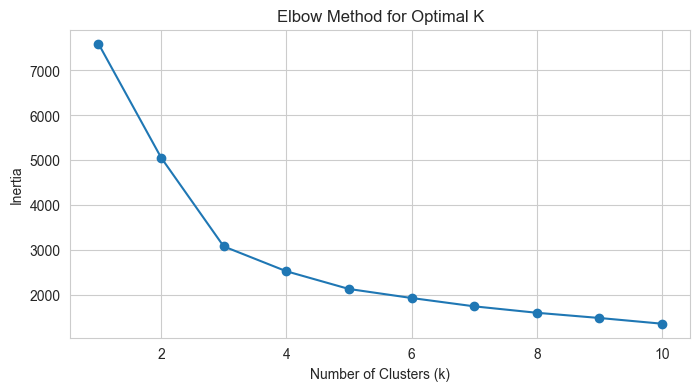

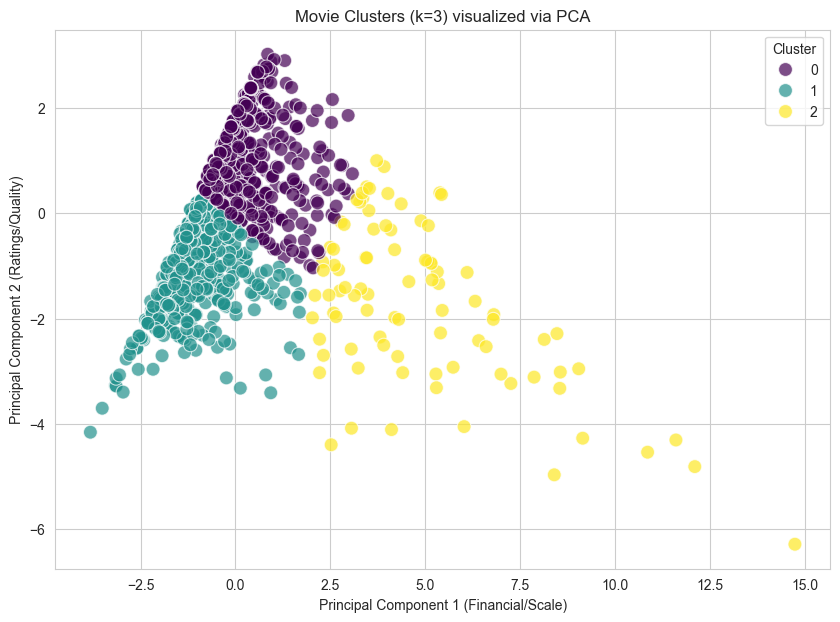

Average values per cluster:


,opening_weekend,domestic_gross,international_gross,net_movie_db,rotten_tom,metacritic
cluster,,,,,,
0,9670642.65,34800434.60,80953150.53,6.47,7.71,6.44
1,11583371.54,31590609.84,82196342.23,5.27,3.28,3.71
2,111953616.09,358466038.84,980319972.45,6.74,7.30,6.15


In [20]:
# selecting numerical features
features = [
    'opening_weekend', 'domestic_gross', 'international_gross',
    'net_movie_db', 'rotten_tom', 'metacritic'
]

# data cleaning and standardization
k_means_df = dataframe[features].dropna().copy()
scaled_data = StandardScaler().fit_transform(k_means_df)

# finding the Optimal K and plotting
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

# running k-means model on the data and merge with release date
k = 3 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
k_means_df['cluster'] = kmeans.fit_predict(scaled_data)

# consolidating and plotting results
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
k_means_df['pca_1'] = pca_data[:, 0]
k_means_df['pca_2'] = pca_data[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='pca_1', y='pca_2', 
    hue='cluster', 
    data=k_means_df, 
    palette='viridis', 
    s=100, alpha=0.7
)
plt.title(f'Movie Clusters (k={k}) visualized via PCA')
plt.xlabel('Principal Component 1 (Financial/Scale)')
plt.ylabel('Principal Component 2 (Ratings/Quality)')
plt.legend(title='Cluster')
plt.show()

# summary of information
print("Average values per cluster:")
display(k_means_df.groupby('cluster')[features].mean())